<a href="https://colab.research.google.com/github/beyzaturku/2209/blob/main/SRCNN_model_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from PIL import Image

### **TensorFlow ile SRCNN Model Tasarımı**

In [4]:
def psnr_metric(y_true, y_pred):
  return tf.image.psnr(y_true, y_pred, max_val=1.0)

In [6]:
def create_srcnn():
  model = models.Sequential()
  model.add(layers.Conv2D(64, (9, 9), padding='same', activation='relu', input_shape=(64, 64, 1)))
  model.add(layers.Dropout(0.2))
  model.add(layers.Conv2D(32, (1, 1), padding='same', activation='relu'))
  model.add(layers.Dropout(0.2))
  model.add(layers.Conv2D(1, (5, 5), padding='same'))

  return model

# Modeli oluştur ve derle
model = create_srcnn()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=[psnr_metric])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           5,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 1)           │             801 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,129 (31.75 KB)

 Trainable params: 8,129 (31.75 KB)

 Non-trainable params: 0 (0.00 B)

### **Veri Yükleme ve Ön İşleme**

In [ ]:
from PIL import Image

In [ ]:
def load_images(hr_dir, lr_dir):
  hr_images = []
  lr_images = []

  hr_files = sorted(os.listdir(hr_dir))
  lr_files = sorted(os.listdir(lr_dir))

  for hr_file, lr_file in zip(hr_files, lr_files):
    # HR görüntüyü yükle
    hr_path = os.path.join(hr_dir, hr_file)
    hr_img = Image.open(hr_path).convert('L')  # Y kanal için gri tonlama, RGB için 'RGB'
    hr_img = np.array(hr_img, dtype=np.float32) / 255.0  # NumPy dizisine çevir

    # LR görüntüyü yükle
    lr_path = os.path.join(lr_dir, lr_file)
    lr_img = Image.open(lr_path).convert('L')
    lr_img = np.array(lr_img, dtype=np.float32) / 255.0

    # Görüntülerin zaten [0,1] olduğunu varsayıyoruz, değilse / 255.0 ekle
    hr_images.append(hr_img)
    lr_images.append(lr_img)

  # Listeyi NumPy dizisine çevir
  hr_images = np.array(hr_images)  # Şekil: (num_samples, height, width)
  lr_images = np.array(lr_images)

  # Kanal boyutunu ekle (TensorFlow Conv2D bekler: [num_samples, height, width, channels])
  hr_images = np.expand_dims(hr_images, axis=-1)  # (num_samples, height, width, 1)
  lr_images = np.expand_dims(lr_images, axis=-1)

  return lr_images, hr_images

train_lr_images, train_hr_images = load_images(
    hr_dir="/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/HR/train",
    lr_dir="/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/LR_upscale/train")

test_lr_images, test_hr_images = load_images(
    hr_dir="/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/HR/test",
    lr_dir="/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/LR_upscale/test")

In [ ]:
# Şekilleri kontrol et
print("Train LR shape:", train_lr_images.shape)
print("Train HR shape:", train_hr_images.shape) # (num_images, height, width, 1)
print("Test LR shape:", test_lr_images.shape)
print("Test HR shape:", test_hr_images.shape)
print("Train LR min-max:", train_lr_images.min(), train_lr_images.max())
print("Train HR min-max:", train_hr_images.min(), train_hr_images.max())

Train LR shape: (1654, 540, 1024, 1)
Train HR shape: (1654, 540, 1024, 1)
Test LR shape: (414, 540, 1024, 1)
Test HR shape: (414, 540, 1024, 1)
Train LR min-max: 0.0 1.0
Train HR min-max: 0.0 1.0


In [ ]:
def augment_images(lr_images, hr_images):
  augmented_lr = []
  augmented_hr = []

  for lr_img, hr_img in zip(lr_images, hr_images):
        # Rastgele yatay çevirme
    if np.random.rand() > 0.5:
        lr_img = np.fliplr(lr_img)
        hr_img = np.fliplr(hr_img)

    crop_size = (64, 64)

    h,w = lr_img.shape[:2]
    if h > crop_size[0] and w > crop_size[1]:
        y = np.random.randint(0, h - crop_size[0])
        x = np.random.randint(0, w - crop_size[1])
        lr_img = lr_img[y:y+crop_size[0], x:x+crop_size[1]]
        hr_img = hr_img[y:y+crop_size[0], x:x+crop_size[1]]

    augmented_lr.append(lr_img)
    augmented_hr.append(hr_img)

  return np.expand_dims(np.array(augmented_lr), -1), np.expand_dims(np.array(augmented_hr), -1)

In [ ]:
# Eğitim
history = model.fit(train_lr_images, train_hr_images,
                    batch_size=8,
                    epochs=100,
                    validation_data=(test_lr_images, test_hr_images))

# Modeli kaydet
model.save('srcnn_model.h5')

Epoch 1/100


ValueError: Dimensions must be equal, but are 64 and 8 for '{{node PSNR/SquaredDifference}} = SquaredDifference[T=DT_FLOAT](PSNR/Identity_1, PSNR/Identity_2)' with input shapes: [8,64,64,1,1], [8,64,64,1].

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Tahmin yap
predictions = model.predict(test_lr_images)

# Metrikleri hesapla
psnr_values = []
ssim_values = []

for i in range(len(test_lr_images)):
    hr_img = test_hr_images[i, :, :, 0]  # Kanal boyutunu kaldır
    pred_img = predictions[i, :, :, 0]

    psnr_val = psnr(hr_img, pred_img, data_range=1.0)
    ssim_val = ssim(hr_img, pred_img, data_range=1.0)

    psnr_values.append(psnr_val)
    ssim_values.append(ssim_val)

print(f'Ortalama PSNR: {np.mean(psnr_values):.2f}')
print(f'Ortalama SSIM: {np.mean(ssim_values):.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step
Ortalama PSNR: 15.29
Ortalama SSIM: 0.3945


In [ ]:
# Yeni bir LR görüntüyü yükle ve tahmin yap
lr_img = tf.keras.preprocessing.image.load_img('/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/LR/test/M0101_img000062.jpg', color_mode='grayscale')
lr_img = tf.keras.preprocessing.image.img_to_array(lr_img) / 255.0
lr_img = np.expand_dims(lr_img, axis=0)  # Batch boyutu ekle

# Tahmin
sr_img = model.predict(lr_img)

# Sonucu kaydet
sr_img = np.clip(sr_img[0] * 255, 0, 255).astype('uint8')  # [0,1] -> [0,255]
tf.keras.preprocessing.image.save_img('sr_output.png', sr_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


In [ ]:
predictions = model.predict(test_lr_images)
predictions = np.clip(predictions, 0, 1)  # Normalizasyon kontrolü
psnr_values = []
ssim_values = []

for i in range(len(test_lr_images)):
    hr_img = test_hr_images[i, :, :, 0]  # Kanalı kaldır
    pred_img = predictions[i, :, :, 0]
    psnr_val = psnr(hr_img, pred_img, data_range=1.0)
    ssim_val = ssim(hr_img, pred_img, data_range=1.0)
    psnr_values.append(psnr_val)
    ssim_values.append(ssim_val)

print(f"Ortalama PSNR: {np.mean(psnr_values):.2f}")
print(f"Ortalama SSIM: {np.mean(ssim_values):.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step
Ortalama PSNR: 15.29
Ortalama SSIM: 0.3945


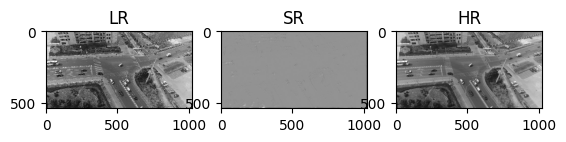

In [ ]:
import matplotlib.pyplot as plt
plt.subplot(1, 3, 1)
plt.imshow(test_lr_images[0, :, :, 0], cmap='gray')
plt.title("LR")
plt.subplot(1, 3, 2)
plt.imshow(predictions[0, :, :, 0], cmap='gray')
plt.title("SR")
plt.subplot(1, 3, 3)
plt.imshow(test_hr_images[0, :, :, 0], cmap='gray')
plt.title("HR")
plt.show()

## **Veri Yükleme - Patchlere Bölme - Data Augmentation**

In [4]:
def load_images(hr_dir, lr_dir):
  hr_images = []
  lr_images = []

  hr_files = sorted(os.listdir(hr_dir))
  lr_files = sorted(os.listdir(lr_dir))

  for hr_file, lr_file in zip(hr_files, lr_files):
    # HR görüntüyü yükle
    hr_path = os.path.join(hr_dir, hr_file)
    hr_img = Image.open(hr_path).convert('L')  # Y kanal için gri tonlama, RGB için 'RGB'
    hr_img = np.array(hr_img, dtype=np.float32) / 255.0  # NumPy dizisine çevir

    # LR görüntüyü yükle
    lr_path = os.path.join(lr_dir, lr_file)
    lr_img = Image.open(lr_path).convert('L')
    lr_img = np.array(lr_img, dtype=np.float32) / 255.0

    # Görüntülerin zaten [0,1] olduğunu varsayıyoruz, değilse / 255.0 ekle
    hr_images.append(hr_img)
    lr_images.append(lr_img)

  # Listeyi NumPy dizisine çevir
  hr_images = np.array(hr_images)  # Şekil: (num_samples, height, width)
  lr_images = np.array(lr_images)

  # Kanal boyutunu ekle (TensorFlow Conv2D bekler: [num_samples, height, width, channels])
  hr_images = np.expand_dims(hr_images, axis=-1)  # (num_samples, height, width, 1)
  lr_images = np.expand_dims(lr_images, axis=-1)

  return lr_images, hr_images

In [5]:
def extract_patches(lr_images, hr_images, patch_size=(64, 64)):
    lr_patches, hr_patches = [], []
    for lr_img, hr_img in zip(lr_images, hr_images):
        h, w = lr_img.shape[:2]
        for y in range(0, h - patch_size[0] + 1, patch_size[0]):
            for x in range(0, w - patch_size[1] + 1, patch_size[1]):
                lr_patch = lr_img[y:y+patch_size[0], x:x+patch_size[1]]
                hr_patch = hr_img[y:y+patch_size[0], x:x+patch_size[1]]
                lr_patches.append(lr_patch)
                hr_patches.append(hr_patch)
    return (np.expand_dims(np.array(lr_patches), -1),
            np.expand_dims(np.array(hr_patches), -1))

In [6]:
"""def augment_patches(lr_patches, hr_patches):
    augmented_lr, augmented_hr = [], []
    for lr_patch, hr_patch in zip(lr_patches, hr_patches):
        # Orijinal patch’i ekle
        augmented_lr.append(lr_patch)
        augmented_hr.append(hr_patch)
        # Yatay çevirme
        if np.random.rand() > 0.5:
            flipped_lr = np.fliplr(lr_patch)
            flipped_hr = np.fliplr(hr_patch)
            augmented_lr.append(flipped_lr)
            augmented_hr.append(flipped_hr)
        # Dikey çevirme
        if np.random.rand() > 0.5:
            flipped_lr = np.flipud(lr_patch)
            flipped_hr = np.flipud(hr_patch)
            augmented_lr.append(flipped_lr)
            augmented_hr.append(flipped_hr)
    return (np.array(augmented_lr), np.array(augmented_hr))"""

In [6]:
# Veriyi hazırla
train_lr_images, train_hr_images = load_images(
    hr_dir="/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/HR/train",
    lr_dir="/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/LR_upscale/train"
)
test_lr_images, test_hr_images = load_images(
    hr_dir="/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/HR/test",
    lr_dir="/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/LR_upscale/test"
)

KeyboardInterrupt: 

In [7]:
# Patch’leri çıkar
train_lr_patches, train_hr_patches = extract_patches(train_lr_images, train_hr_images)
test_lr_patches, test_hr_patches = extract_patches(test_lr_images, test_hr_images)

# Patch’lere augmentation uygula (sadece eğitim setine)
#train_lr_patches, train_hr_patches = augment_patches(train_lr_patches, train_hr_patches)

In [8]:
# Şekilleri kontrol et
print("Train LR patches shape:", train_lr_patches.shape)
print("Train HR patches shape:", train_hr_patches.shape)
print("Test LR patches shape:", test_lr_patches.shape)
print("Test HR patches shape:", test_hr_patches.shape)

Train LR patches shape: (211712, 64, 64, 1, 1)
Train HR patches shape: (211712, 64, 64, 1, 1)
Test LR patches shape: (52992, 64, 64, 1, 1)
Test HR patches shape: (52992, 64, 64, 1, 1)


In [12]:
# Model
def psnr_metric(y_true, y_pred):
  # Sıkıştırılmış boyutu kaldır
    y_true = tf.squeeze(y_true, axis=-1)
    y_pred = tf.squeeze(y_pred, axis=-1)
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def create_srcnn(input_shape=(64, 64, 1)):
    model = models.Sequential()
    model.add(layers.Conv2D(128, (9, 9), padding='same', activation='relu', input_shape=input_shape,
                            kernel_regularizer=tf.keras.regularizers.l2(0.01)))
    model.add(layers.Dropout(0.2))
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                            kernel_regularizer=tf.keras.regularizers.l2(0.01)))
    model.add(layers.Dropout(0.2))
    model.add(layers.Conv2D(32, (1, 1), padding='same', activation='relu'))
    model.add(layers.Conv2D(1, (5, 5), padding='same'))
    return model

model = create_srcnn()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=[psnr_metric])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Eğitim
history = model.fit(train_lr_patches, train_hr_patches,
                    batch_size=4,
                    epochs=100,
                    validation_data=(test_lr_patches, test_hr_patches),
                    callbacks=[tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
                               tf.keras.callbacks.EarlyStopping(monitor='val_psnr_metric', mode='max',
                                                                patience=10, restore_best_weights=True)])

Epoch 1/100


ValueError: Dimensions must be equal, but are 64 and 4 for '{{node PSNR/SquaredDifference}} = SquaredDifference[T=DT_FLOAT](PSNR/Identity_1, PSNR/Identity_2)' with input shapes: [4,64,64,1], [4,64,64].

## **Veri Bellekte Tutmayan Kod**

In [7]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [9]:
# Veri yolları
train_hr_dir = "/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/HR/train"
train_lr_dir = "/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/LR_upscale/train"
test_hr_dir = "/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/HR/test"
test_lr_dir = "/content/drive/MyDrive/srcnn_dataset/SRCNN_Dataset/LR_upscale/test"

In [10]:
# Gerçek zamanlı patch çıkarma fonksiyonu
def generate_patches(hr_dir, lr_dir, patch_size=32, batch_size=8):
    hr_files = sorted(os.listdir(hr_dir))
    lr_files = sorted(os.listdir(lr_dir))

    while True:  # Sonsuz döngü, generator için
        lr_batch = []
        hr_batch = []
        for _ in range(batch_size):
            # Rastgele bir görüntü seç
            idx = np.random.randint(0, len(hr_files))
            hr_path = os.path.join(hr_dir, hr_files[idx])
            lr_path = os.path.join(lr_dir, lr_files[idx])

            # Görüntüyü yükle
            hr_img = Image.open(hr_path).convert('L')
            hr_img = np.array(hr_img, dtype=np.float32) / 255.0
            lr_img = Image.open(lr_path).convert('L')
            lr_img = np.array(lr_img, dtype=np.float32) / 255.0

            # Rastgele bir patch çıkar
            h, w = hr_img.shape
            y = np.random.randint(0, h - patch_size + 1)
            x = np.random.randint(0, w - patch_size + 1)
            hr_patch = hr_img[y:y+patch_size, x:x+patch_size]
            lr_patch = lr_img[y:y+patch_size, x:x+patch_size]

            lr_batch.append(lr_patch)
            hr_batch.append(hr_patch)

        # Batch’i hazırla
        lr_batch = np.expand_dims(np.array(lr_batch), -1)  # [batch_size, 32, 32, 1]
        hr_batch = np.expand_dims(np.array(hr_batch), -1)  # [batch_size, 32, 32, 1]
        yield lr_batch, hr_batch

In [11]:
# Model tanımı
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def create_optimized_srcnn(input_shape=(32, 32, 1)):
    model = models.Sequential()
    model.add(layers.Conv2D(128, (9, 9), padding='same', activation='relu', input_shape=input_shape,
                            kernel_regularizer=tf.keras.regularizers.l2(0.01)))
    model.add(layers.Dropout(0.2))
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                            kernel_regularizer=tf.keras.regularizers.l2(0.01)))
    model.add(layers.Dropout(0.2))
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.Conv2D(1, (5, 5), padding='same'))
    return model

In [12]:
# Modeli oluştur ve derle
model = create_optimized_srcnn()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=[psnr_metric])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Eğitim generator’ları
train_generator = generate_patches(train_hr_dir, train_lr_dir, patch_size=32, batch_size=8)
val_generator = generate_patches(test_hr_dir, test_lr_dir, patch_size=32, batch_size=8)

In [14]:
# Eğitim adımları
train_steps = len(os.listdir(train_hr_dir)) // 8  # Her epoch’ta kaç batch
val_steps = len(os.listdir(test_hr_dir)) // 8

In [15]:
# Eğitim
history = model.fit(train_generator,
                    steps_per_epoch=train_steps,
                    epochs=100,
                    validation_data=val_generator,
                    validation_steps=val_steps,
                    callbacks=[tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
                               tf.keras.callbacks.EarlyStopping(monitor='val_psnr_metric', mode='max',
                                                                patience=10, restore_best_weights=True)])

Epoch 1/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 808s 4s/step - loss: 0.3026 - psnr_metric: 18.3203 - val_loss: 0.0142 - val_psnr_metric: 22.2020 - learning_rate: 0.0010
Epoch 2/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - loss: 0.0115 - psnr_metric: 23.3314 - val_loss: 0.0085 - val_psnr_metric: 24.5130 - learning_rate: 0.0010
Epoch 3/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 140s 683ms/step - loss: 0.0098 - psnr_metric: 22.8191 - val_loss: 0.0076 - val_psnr_metric: 24.3435 - learning_rate: 0.0010
Epoch 4/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 76s 373ms/step - loss: 0.0090 - psnr_metric: 22.9871 - val_loss: 0.0098 - val_psnr_metric: 22.1232 - learning_rate: 0.0010
Epoch 5/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 45s 220ms/step - loss: 0.0082 - psnr_metric: 23.6016 - val_loss: 0.0075 - val_psnr_metric: 24.2780 - learning_rate: 0.0010
Epoch 6/100
206/206 ━━━━━━━━━━━━━━━━━━━━ 32s 156ms/step - loss: 0.0077 - psnr_metric: 23.7855 - val_loss: 0.0083 - val_psnr_metric: 23.0729 - learning_rate: 0.0010
Epoch 7/100
206/206

In [17]:
# Manuel değerlendirme (RAM’i az kullanmak için sınırlı örnek)
def evaluate_model(model, hr_dir, lr_dir, num_samples=50):
    hr_files = sorted(os.listdir(hr_dir))
    lr_files = sorted(os.listdir(lr_dir))
    psnr_values = []
    ssim_values = []

    for _ in range(num_samples):
        idx = np.random.randint(0, len(hr_files))
        hr_path = os.path.join(hr_dir, hr_files[idx])
        lr_path = os.path.join(lr_dir, lr_files[idx])

        hr_img = Image.open(hr_path).convert('L')
        hr_img = np.array(hr_img, dtype=np.float32) / 255.0
        lr_img = Image.open(lr_path).convert('L')
        lr_img = np.array(lr_img, dtype=np.float32) / 255.0

        lr_input = np.expand_dims(np.expand_dims(lr_img, -1), 0)  # [1, height, width, 1]
        pred_img = model.predict(lr_input, verbose=0)[0, :, :, 0]  # [height, width]

        psnr_val = psnr(hr_img, pred_img, data_range=1.0)
        ssim_val = ssim(hr_img, pred_img, data_range=1.0)
        psnr_values.append(psnr_val)
        ssim_values.append(ssim_val)

    print(f"Ortalama PSNR: {np.mean(psnr_values):.2f}")
    print(f"Ortalama SSIM: {np.mean(ssim_values):.4f}")

# Değerlendirme
evaluate_model(model, test_hr_dir, test_lr_dir)

Ortalama PSNR: 22.84
Ortalama SSIM: 0.5959
